In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv
/kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data/A_Z Handwritten Data.csv


In [44]:
import os, random, glob, json, gc
os.environ["PYTHONHASHSEED"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ---- reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ---- configuration (mirrors the proposal's hyperparameters) ----
BATCH         = 128      # batch size
EPOCHS        = 20       # max epochs for the custom CNN (early stopping may stop sooner)
IMG_TL        = 32       # input size for MobileNetV2 (its minimum is 32x32)
BATCH_TL      = 128
HEAD_EPOCHS   = 5        # transfer learning: train the new head
FT_EPOCHS     = 3        # transfer learning: fine-tune top layers
SAMPLE_FRACTION   = 1.0  # set < 1.0 (e.g. 0.2) for a quick test run on part of the data
USE_CLASS_WEIGHTS = True # handle imbalance by weighting rare letters more
DO_FINETUNE       = True

AUTOTUNE = tf.data.AUTOTUNE
LETTERS  = [chr(65 + i) for i in range(26)]   # 0->A ... 25->Z
NUM_CLASSES = 26

# ---- output folders (Kaggle writes to /kaggle/working) ----
WORK = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
FIG_DIR   = os.path.join(WORK, "figures"); os.makedirs(FIG_DIR, exist_ok=True)    # figures saved as PDF
TABLE_DIR = os.path.join(WORK, "tables");  os.makedirs(TABLE_DIR, exist_ok=True)  # tables saved as CSV
MODEL_DIR = os.path.join(WORK, "models");  os.makedirs(MODEL_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [45]:
# Find the CSV inside the Kaggle input folder (robust to exact folder name)
csv_candidates = glob.glob("/kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv", recursive=True)
print("CSV files found:", csv_candidates)

csv_path = None
for c in csv_candidates:
    if "handwritten" in c.lower() or "a_z" in c.lower().replace(" ", "_"):
        csv_path = c; break
if csv_path is None and csv_candidates:
    csv_path = csv_candidates[0]
assert csv_path is not None, "Could not find the dataset CSV under /kaggle/input"
print("Using:", csv_path)

# Read as uint8 (labels 0-25 and pixels 0-255 all fit in a byte) -> ~290 MB
df = pd.read_csv(csv_path, header=None, dtype=np.uint8)
print("Raw shape:", df.shape)   # expect (~372451, 785)

# Split into labels and pixel features
labels = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:].to_numpy()
del df; gc.collect()

print("Labels range:", labels.min(), "to", labels.max(), "| unique:", len(np.unique(labels)))
print("Pixels shape:", X.shape, "| min/max:", X.min(), X.max())

CSV files found: ['/kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv']
Using: /kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv
Raw shape: (372451, 785)
Labels range: 0 to 25 | unique: 26
Pixels shape: (372451, 784) | min/max: 0 255


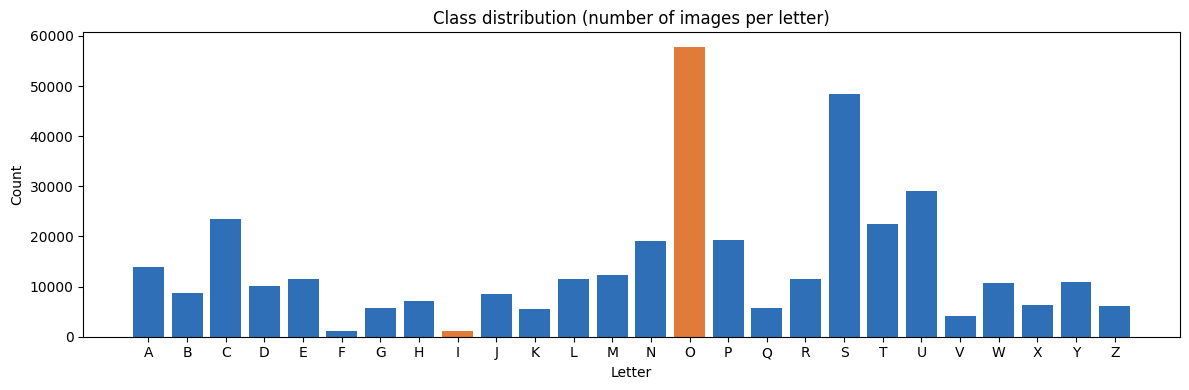

Most common: O 57825
Least common: I 1120
Imbalance ratio (max/min): 51.6


In [46]:
# ---- class distribution ----
counts = pd.Series(labels).value_counts().sort_index()
counts.index = LETTERS

# save the distribution as a table (CSV)
pd.DataFrame({"letter": LETTERS, "count": counts.values}).to_csv(
    os.path.join(TABLE_DIR, "class_distribution.csv"), index=False)

plt.figure(figsize=(12, 4))
colors = ["#E07B39" if (c == counts.max() or c == counts.min()) else "#2E6FB7" for c in counts]
plt.bar(counts.index, counts.values, color=colors)
plt.title("Class distribution (number of images per letter)")
plt.xlabel("Letter"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_class_distribution.pdf"), dpi=150)
plt.show()

print("Most common:", counts.idxmax(), int(counts.max()))
print("Least common:", counts.idxmin(), int(counts.min()))
print("Imbalance ratio (max/min): %.1f" % (counts.max() / counts.min()))

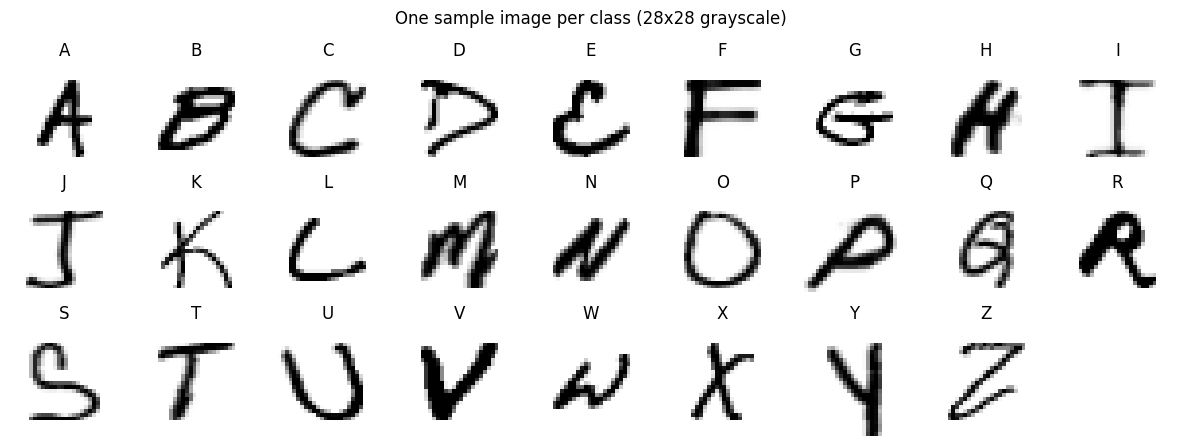

In [47]:
# ---- one sample image per class ----
fig, axes = plt.subplots(3, 9, figsize=(12, 4.5))
axes = axes.ravel()
for i in range(27):
    axes[i].axis("off")
    if i < 26:
        idx = np.where(labels == i)[0][0]            # first image of class i
        axes[i].imshow(X[idx].reshape(28, 28), cmap="gray_r")
        axes[i].set_title(LETTERS[i])
fig.suptitle("One sample image per class (28x28 grayscale)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_sample_letters.pdf"), dpi=150, bbox_inches="tight")
plt.show()

In [48]:
# Reshape to (N, 28, 28, 1). Keep uint8 for now to save memory; scaling happens in the model.
X = X.reshape(-1, 28, 28, 1)
print("Image tensor shape:", X.shape, "| dtype:", X.dtype)

# Optional subsampling for a quick test run (stratified). Full data when SAMPLE_FRACTION == 1.0
if SAMPLE_FRACTION < 1.0:
    idx, _ = train_test_split(np.arange(len(labels)), train_size=SAMPLE_FRACTION,
                              stratify=labels, random_state=SEED)
    X, labels = X[idx], labels[idx]
    print("Subsampled to:", X.shape)

Image tensor shape: (372451, 28, 28, 1) | dtype: uint8


In [49]:
# First split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, labels, test_size=0.15, stratify=labels, random_state=SEED)

# Then split the remaining 85% into train (70% of total) and validation (15% of total)
# 0.15 / 0.85 = 0.1765 of the remainder goes to validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED)

del X, labels, X_temp, y_temp; gc.collect()

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
# verify proportions are preserved (should be nearly identical across splits)
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    frac = pd.Series(y).value_counts(normalize=True).sort_index().round(3).values
    print(name, "class fraction (first 5 letters):", frac[:5])

Train: (260706, 28, 28, 1) | Val: (55877, 28, 28, 1) | Test: (55868, 28, 28, 1)
train class fraction (first 5 letters): [0.037 0.023 0.063 0.027 0.031]
val class fraction (first 5 letters): [0.037 0.023 0.063 0.027 0.031]
test class fraction (first 5 letters): [0.037 0.023 0.063 0.027 0.031]


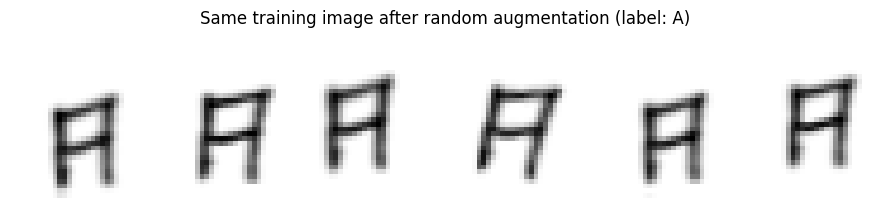

In [50]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),                       # +/- ~11 degrees
    tf.keras.layers.RandomTranslation(0.10, 0.10),              # +/- 10% shift
    tf.keras.layers.RandomZoom(0.10),                           # +/- 10% zoom
], name="data_augmentation")

# Visualise augmentation on one training image
sample = tf.cast(X_train[0:1], tf.float32) / 255.0
plt.figure(figsize=(9, 2.2))
for i in range(6):
    aug = data_augmentation(sample, training=True)
    plt.subplot(1, 6, i + 1)
    plt.imshow(tf.squeeze(aug), cmap="gray_r"); plt.axis("off")
plt.suptitle("Same training image after random augmentation (label: %s)" % LETTERS[y_train[0]])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_augmentation_examples.pdf"), dpi=150, bbox_inches="tight")
plt.show()

In [51]:
def make_ds(Xa, ya, training=False, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((Xa, ya))
    if training:
        ds = ds.shuffle(min(len(Xa), 10000), seed=SEED)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch).prefetch(AUTOTUNE)

# Custom-CNN datasets (test/val NOT shuffled so labels stay aligned with predictions)
train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val,   training=False)
test_ds  = make_ds(X_test,  y_test,  training=False)

def make_ds_tl(Xa, ya, training=False, batch=BATCH_TL):
    ds = tf.data.Dataset.from_tensor_slices((Xa, ya))
    if training:
        ds = ds.shuffle(min(len(Xa), 10000), seed=SEED)
    def prep(x, y):
        x = tf.cast(x, tf.float32)
        x = tf.image.resize(x, [IMG_TL, IMG_TL])               # 28x28 -> 32x32
        x = tf.image.grayscale_to_rgb(x)                       # 1 channel -> 3 channels
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # scales to [-1, 1]
        return x, y
    ds = ds.map(prep, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch).prefetch(AUTOTUNE)

train_ds_tl = make_ds_tl(X_train, y_train, training=True)
val_ds_tl   = make_ds_tl(X_val,   y_val,   training=False)
test_ds_tl  = make_ds_tl(X_test,  y_test,  training=False)
print("Pipelines ready.")

Pipelines ready.


In [52]:
def build_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Rescaling(1.0 / 255),                  # normalise 0-255 -> 0-1
        data_augmentation,                                     # train-time only
        tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="custom_cnn")
    return model

cnn = build_cnn()
cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,522 (1.50 MB)

 Trainable params: 394,522 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

# class weights from the TRAIN labels only
class_weight = None
if USE_CLASS_WEIGHTS:
    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight = dict(zip(classes.tolist(), weights.tolist()))
    print("Example class weights:", {LETTERS[k]: round(v, 2) for k, v in list(class_weight.items())[:5]})

cnn_ckpt = os.path.join(MODEL_DIR, "cnn_best.keras")
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    tf.keras.callbacks.ModelCheckpoint(cnn_ckpt, monitor="val_loss", save_best_only=True),
]

history = cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                  class_weight=class_weight, callbacks=callbacks, verbose=1)

Example class weights: {'A': 1.03, 'B': 1.65, 'C': 0.61, 'D': 1.41, 'E': 1.25}
Epoch 1/20
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8927 - loss: 0.3613 - val_accuracy: 0.9587 - val_loss: 0.1498 - learning_rate: 0.0010
Epoch 2/20
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9599 - loss: 0.1381 - val_accuracy: 0.9807 - val_loss: 0.0742 - learning_rate: 0.0010
Epoch 3/20
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9674 - loss: 0.1105 - val_accuracy: 0.9835 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 4/20
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9719 - loss: 0.0941 - val_accuracy: 0.9860 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 5/20
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9739 - loss: 0.0883 - val_accuracy: 0.9863 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 6/20
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9763 - loss: 0.0791 - val_accuracy: 0.9863 - val_loss: 0.0572 - learning_rate

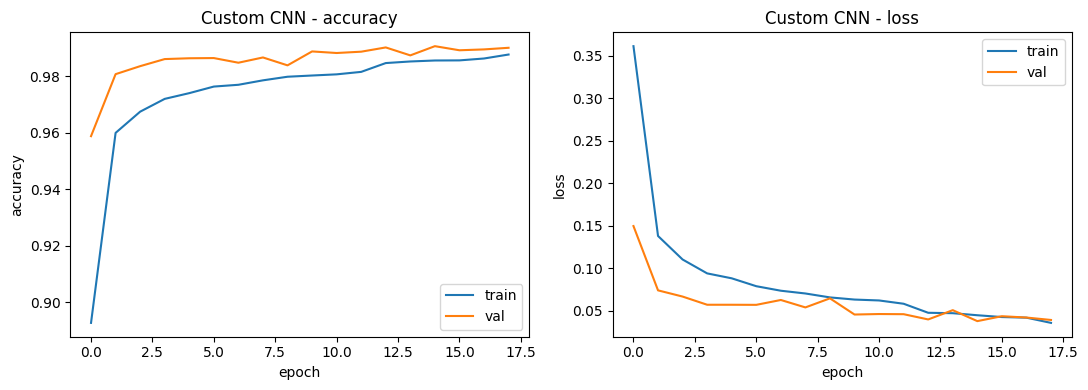

In [54]:
def plot_curves(hist, title, fname):
    h = hist.history
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
    a1.plot(h["accuracy"], label="train"); a1.plot(h["val_accuracy"], label="val")
    a1.set_title(title + " - accuracy"); a1.set_xlabel("epoch"); a1.set_ylabel("accuracy"); a1.legend()
    a2.plot(h["loss"], label="train"); a2.plot(h["val_loss"], label="val")
    a2.set_title(title + " - loss"); a2.set_xlabel("epoch"); a2.set_ylabel("loss"); a2.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150)
    plt.show()

plot_curves(history, "Custom CNN", "04_cnn_curves.pdf")

In [55]:
def build_mobilenet():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_TL, IMG_TL, 3), include_top=False, weights="imagenet")
    base.trainable = False                                     # stage 1: freeze the base
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_TL, IMG_TL, 3)),
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="mobilenetv2_transfer")
    return model, base

mnet, base = build_mobilenet()
mnet.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])

mnet_ckpt = os.path.join(MODEL_DIR, "mobilenet_best.keras")
tl_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(mnet_ckpt, monitor="val_loss", save_best_only=True),
]

# Stage 1: train the head
hist_tl = mnet.fit(train_ds_tl, validation_data=val_ds_tl,
                   epochs=HEAD_EPOCHS, class_weight=class_weight,
                   callbacks=tl_callbacks, verbose=1)

/tmp/ipykernel_58/4230195027.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Epoch 1/5
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.3695 - loss: 2.1722 - val_accuracy: 0.5586 - val_loss: 1.6065
Epoch 2/5
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.4083 - loss: 1.9617 - val_accuracy: 0.5557 - val_loss: 1.5420
Epoch 3/5
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.4191 - loss: 1.8956 - val_accuracy: 0.5793 - val_loss: 1.4654
Epoch 4/5
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.4262 - loss: 1.8623 - val_accuracy: 0.5836 - val_loss: 1.4491
Epoch 5/5
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.4306 - loss: 1.8393 - val_accuracy: 0.5735 - val_loss: 1.4463


In [56]:
# Stage 2: fine-tune the top layers of the base at a low learning rate
if DO_FINETUNE:
    base.trainable = True
    for layer in base.layers[:-30]:        # keep the lower layers frozen
        layer.trainable = False
    mnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist_ft = mnet.fit(train_ds_tl, validation_data=val_ds_tl,
                       epochs=FT_EPOCHS, class_weight=class_weight,
                       callbacks=tl_callbacks, verbose=1)

Epoch 1/3
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.3275 - loss: 9.3224 - val_accuracy: 0.1961 - val_loss: 3.1270
Epoch 2/3
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.5096 - loss: 2.2639 - val_accuracy: 0.5769 - val_loss: 1.5568


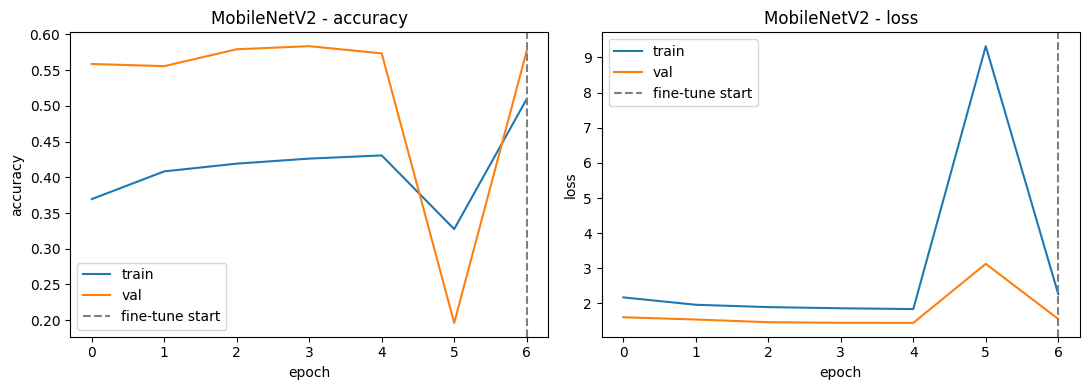

Saved: 04b_mobilenetv2_curves.pdf


In [57]:
# MobileNetV2 training curves (stage 1 + stage 2 combined)
import matplotlib.pyplot as plt
import os

# combine stage 1 and stage 2 history if fine-tuning was done
h_acc  = hist_tl.history["accuracy"]
h_val  = hist_tl.history["val_accuracy"]
h_loss = hist_tl.history["loss"]
h_vloss= hist_tl.history["val_loss"]

if DO_FINETUNE:
    h_acc   += hist_ft.history["accuracy"]
    h_val   += hist_ft.history["val_accuracy"]
    h_loss  += hist_ft.history["loss"]
    h_vloss += hist_ft.history["val_loss"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(h_acc,  label="train"); a1.plot(h_val,  label="val")
a1.set_title("MobileNetV2 - accuracy"); a1.set_xlabel("epoch")
a1.set_ylabel("accuracy"); a1.legend()
# mark where fine-tuning starts
if DO_FINETUNE:
    a1.axvline(len(hist_tl.history["accuracy"])-1, color="gray",
               linestyle="--", label="fine-tune start")
    a1.legend()

a2.plot(h_loss, label="train"); a2.plot(h_vloss, label="val")
a2.set_title("MobileNetV2 - loss"); a2.set_xlabel("epoch")
a2.set_ylabel("loss"); a2.legend()
if DO_FINETUNE:
    a2.axvline(len(hist_tl.history["loss"])-1, color="gray",
               linestyle="--", label="fine-tune start")
    a2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04b_mobilenetv2_curves.pdf"), dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: 04b_mobilenetv2_curves.pdf")

In [58]:
cnn_test_loss,  cnn_test_acc  = cnn.evaluate(test_ds,  verbose=0)
mnet_test_loss, mnet_test_acc = mnet.evaluate(test_ds_tl, verbose=0)
print("Custom CNN   - test accuracy: %.4f" % cnn_test_acc)
print("MobileNetV2  - test accuracy: %.4f" % mnet_test_acc)

# Probabilities and predicted classes (datasets are not shuffled -> aligned with y_test)
cnn_prob  = cnn.predict(test_ds,  verbose=0)
mnet_prob = mnet.predict(test_ds_tl, verbose=0)
cnn_pred  = cnn_prob.argmax(axis=1)
mnet_pred = mnet_prob.argmax(axis=1)

Custom CNN   - test accuracy: 0.9907
MobileNetV2  - test accuracy: 0.1963


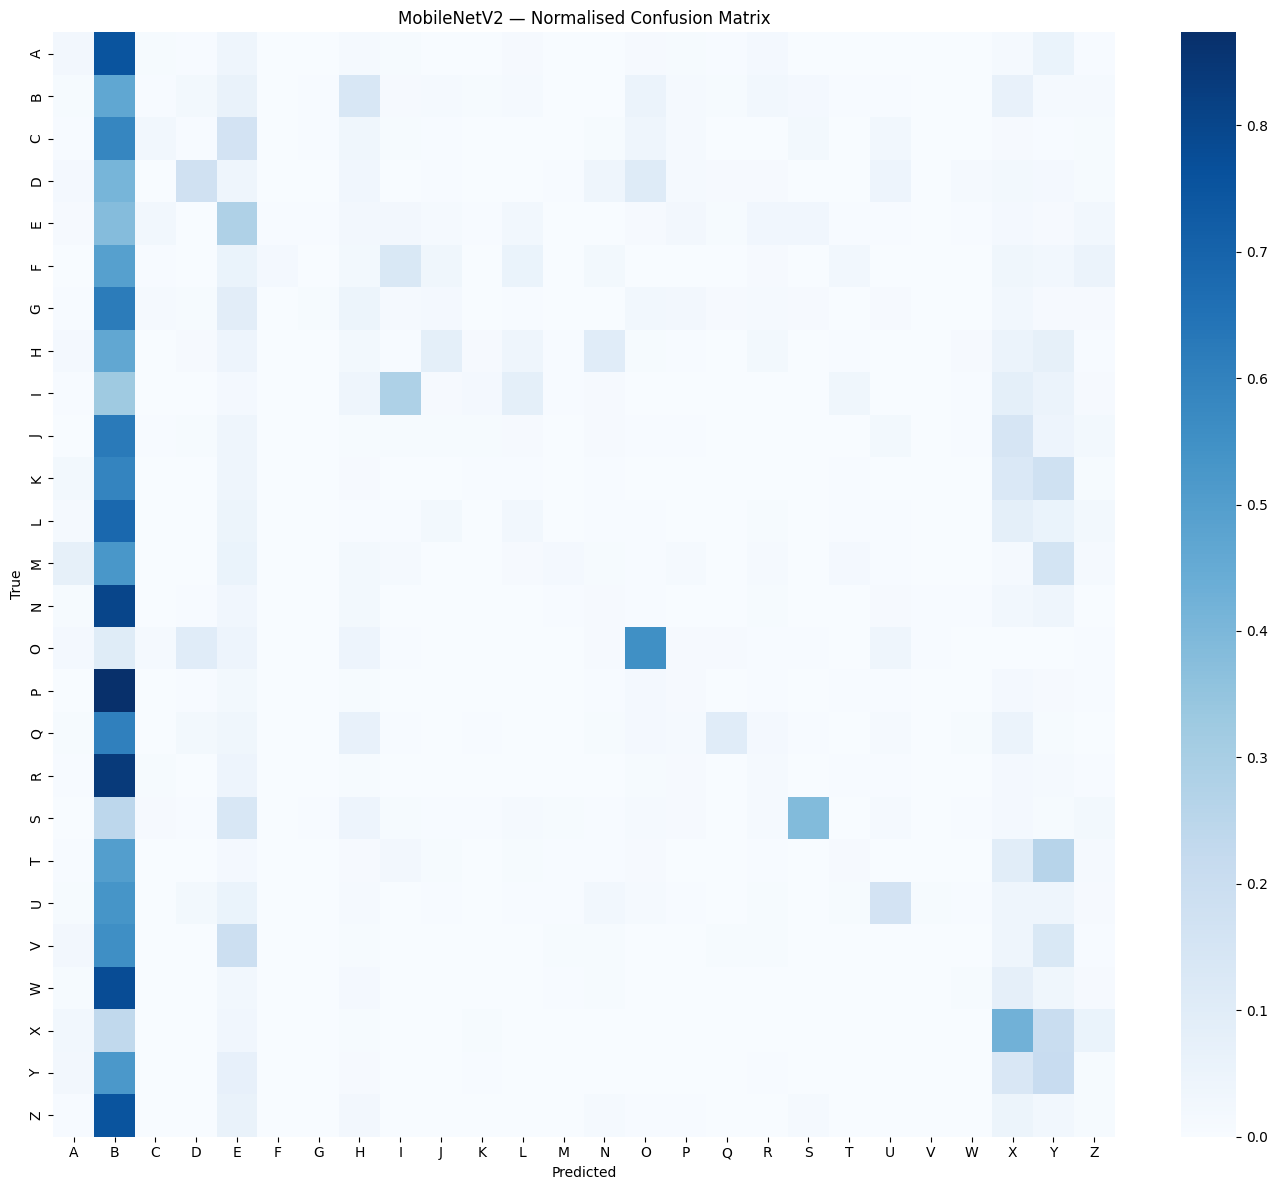

Saved: 05b_mnet_confusion_matrix.pdf


In [59]:
# MobileNetV2 confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm_mnet = confusion_matrix(y_test, mnet_pred, normalize="true")

plt.figure(figsize=(14, 12))
sns.heatmap(cm_mnet, annot=False, fmt=".2f", cmap="Blues",
            xticklabels=LETTERS, yticklabels=LETTERS)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("MobileNetV2 — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05b_mnet_confusion_matrix.pdf"), dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: 05b_mnet_confusion_matrix.pdf")

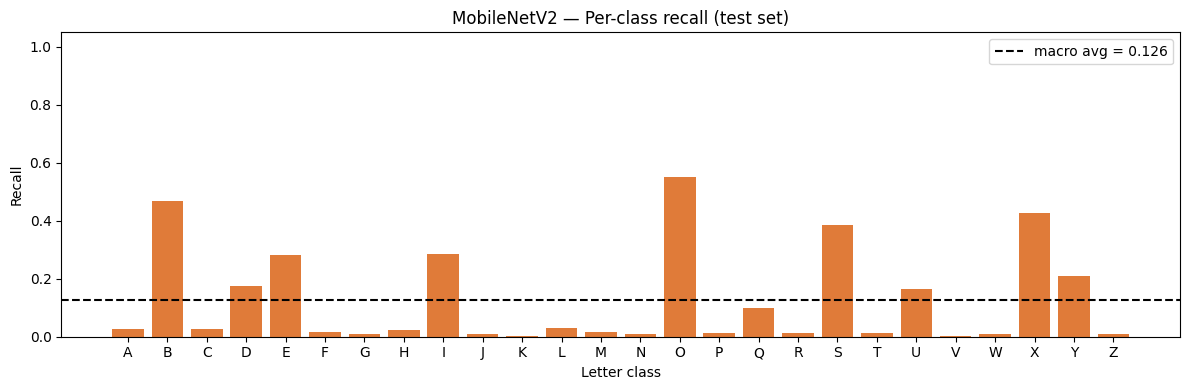

Saved: 06b_mnet_per_class_recall.pdf


In [60]:
# MobileNetV2 per-class recall bar chart
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import pandas as pd

rec_mnet = recall_score(y_test, mnet_pred, average=None, zero_division=0)
macro_mnet = rec_mnet.mean()

# save CSV
pd.DataFrame({"letter": LETTERS, "recall": rec_mnet}).to_csv(
    os.path.join(TABLE_DIR, "mnet_per_class_recall.csv"), index=False)

# same colour logic as CNN — orange = minority classes
from sklearn.metrics import confusion_matrix
order_counts = pd.Series(y_test).value_counts()
thresh = order_counts.quantile(0.25)
bar_colors = ["#E07B39" if order_counts.get(i, 0) <= thresh
              else "#E07B39" if rec_mnet[i] < 0.5
              else "#E07B39" for i in range(NUM_CLASSES)]
# simpler: colour all bars orange since MobileNetV2 fails broadly
bar_colors = ["#E07B39"] * NUM_CLASSES

plt.figure(figsize=(12, 4))
plt.bar(LETTERS, rec_mnet, color=bar_colors)
plt.axhline(macro_mnet, color="black", linestyle="--",
            label=f"macro avg = {macro_mnet:.3f}")
plt.ylim(0, 1.05); plt.xlabel("Letter class"); plt.ylabel("Recall")
plt.title("MobileNetV2 — Per-class recall (test set)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06b_mnet_per_class_recall.pdf"), dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: 06b_mnet_per_class_recall.pdf")

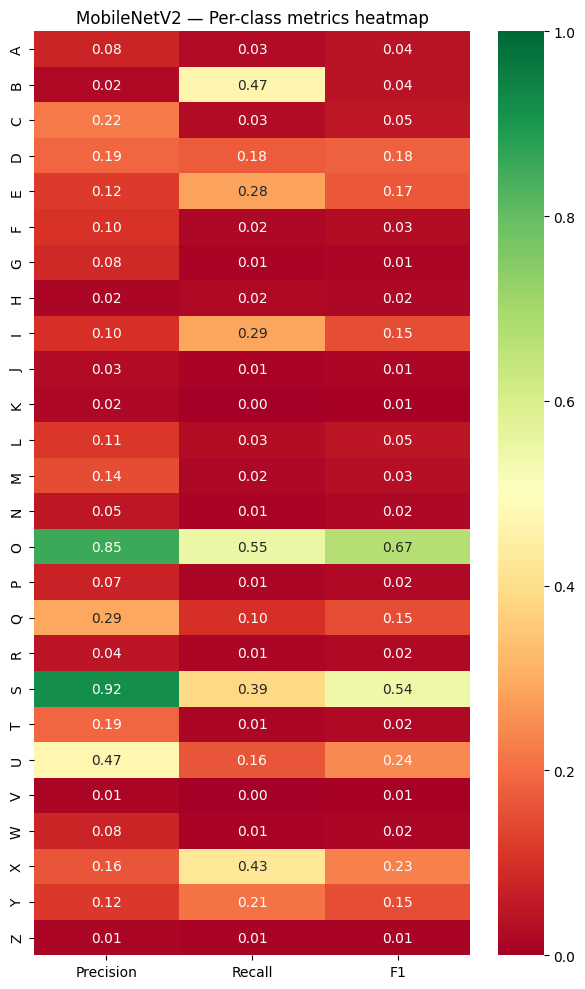

Saved: 07b_mnet_class_report_heatmap.pdf


In [61]:
# MobileNetV2 classification report — heatmap
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report_mnet = classification_report(y_test, mnet_pred,
                                    target_names=LETTERS,
                                    output_dict=True,
                                    zero_division=0)

# save CSV
pd.DataFrame(report_mnet).transpose().to_csv(
    os.path.join(TABLE_DIR, "mnet_classification_report.csv"))

# heatmap of precision / recall / f1 per class (rows = letters)
df_report = pd.DataFrame(report_mnet).transpose().loc[
    LETTERS, ["precision", "recall", "f1-score"]]

plt.figure(figsize=(6, 10))
sns.heatmap(df_report.astype(float), annot=True, fmt=".2f",
            cmap="RdYlGn", vmin=0, vmax=1,
            xticklabels=["Precision","Recall","F1"],
            yticklabels=LETTERS)
plt.title("MobileNetV2 — Per-class metrics heatmap")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07b_mnet_class_report_heatmap.pdf"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07b_mnet_class_report_heatmap.pdf")

Classification report - Custom CNN

              precision    recall  f1-score   support

           A      0.995     0.997     0.996      2081
           B      0.995     0.998     0.996      1300
           C      0.991     0.993     0.992      3511
           D      0.953     0.974     0.964      1520
           E      0.996     0.987     0.992      1716
           F      0.951     1.000     0.975       174
           G      0.978     0.990     0.984       864
           H      0.981     0.990     0.985      1083
           I      0.960     1.000     0.980       168
           J      0.970     0.989     0.979      1274
           K      0.979     0.995     0.987       841
           L      0.991     0.991     0.991      1738
           M      0.993     0.996     0.995      1850
           N      0.992     0.986     0.989      2852
           O      0.995     0.989     0.992      8674
           P      0.997     0.992     0.994      2901
           Q      0.973     0.994     0.984  

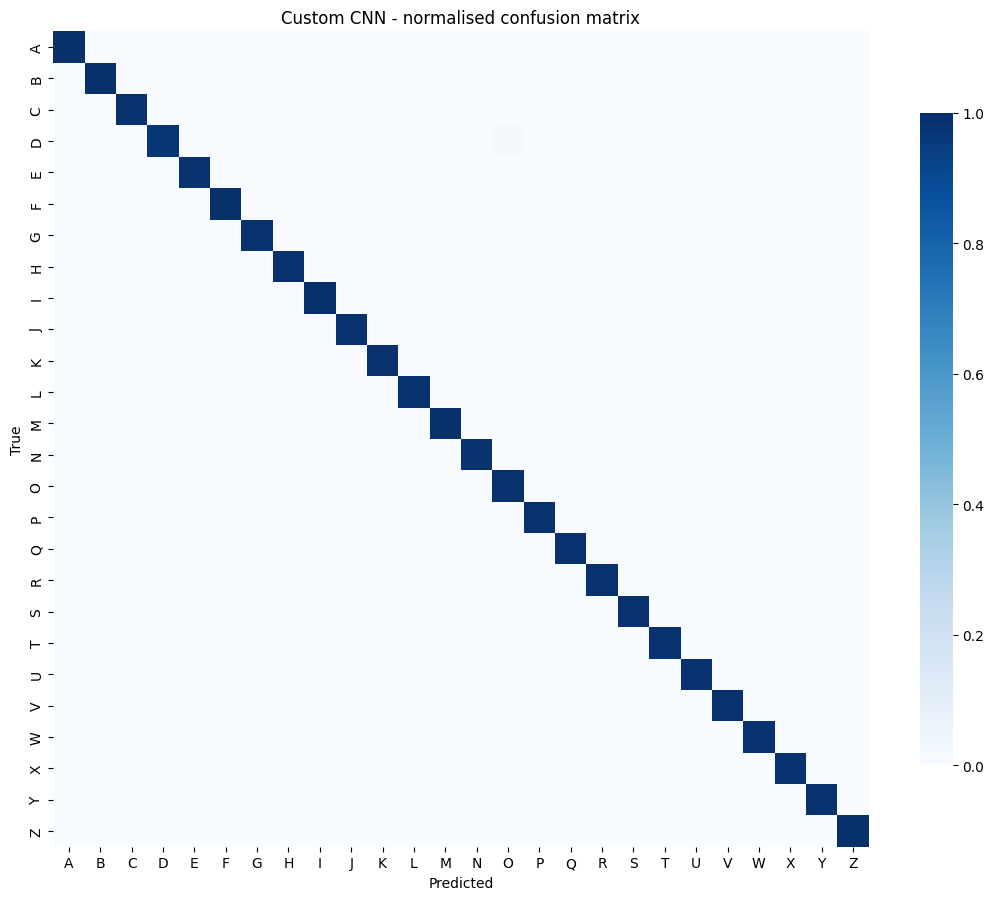

Most confused (true -> predicted, count):
  O -> D : 56
  D -> O : 29
  U -> V : 21
  N -> W : 18
  O -> Q : 13
  P -> D : 13
  W -> N : 13
  C -> L : 10
  S -> J : 10
  U -> O : 10


In [62]:
print("Classification report - Custom CNN\n")
print(classification_report(y_test, cnn_pred, target_names=LETTERS, digits=3))

# Save the report to disk as well (CSV table)
report_dict = classification_report(y_test, cnn_pred, target_names=LETTERS,
                                     output_dict=True, zero_division=0)
pd.DataFrame(report_dict).transpose().to_csv(
    os.path.join(TABLE_DIR, "cnn_classification_report.csv"))

# Normalised confusion matrix (row = true class)
cm = confusion_matrix(y_test, cnn_pred, normalize="true")
plt.figure(figsize=(11, 9))
sns.heatmap(cm, xticklabels=LETTERS, yticklabels=LETTERS, cmap="Blues",
            vmin=0, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Custom CNN - normalised confusion matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_confusion_matrix.pdf"), dpi=150)
plt.show()

# Top confused pairs (off-diagonal), useful for RQ2
cm_counts = confusion_matrix(y_test, cnn_pred)
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_counts[i, j] > 0:
            pairs.append((LETTERS[i], LETTERS[j], cm_counts[i, j]))
pairs.sort(key=lambda t: t[2], reverse=True)
pd.DataFrame(pairs, columns=["true", "predicted", "count"]).to_csv(
    os.path.join(TABLE_DIR, "confused_pairs.csv"), index=False)
print("Most confused (true -> predicted, count):")
for t in pairs[:10]:
    print("  %s -> %s : %d" % t)

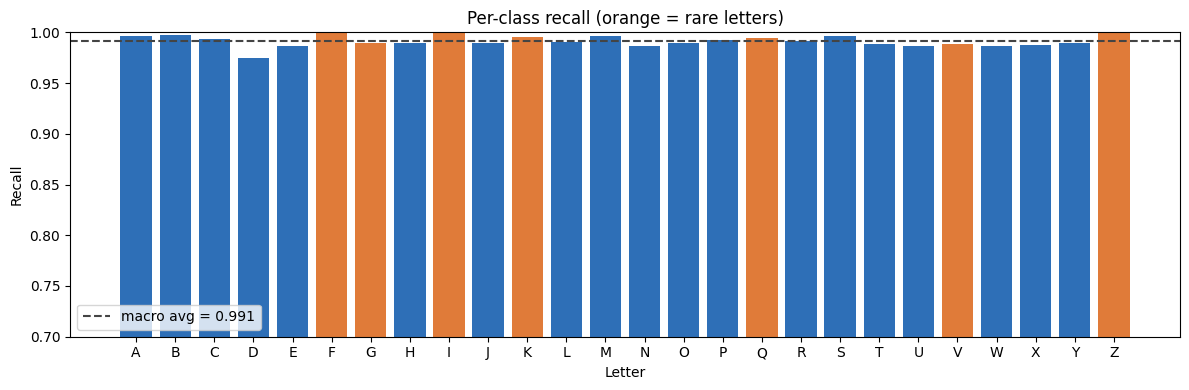

Lowest-recall letters: [('D', np.float64(0.974)), ('N', np.float64(0.986)), ('W', np.float64(0.986)), ('E', np.float64(0.987)), ('U', np.float64(0.987))]


In [63]:
## 13. Per-class recall (imbalance analysis, RQ3)
rec = recall_score(y_test, cnn_pred, average=None)
macro = rec.mean()
pd.DataFrame({"letter": LETTERS, "recall": rec}).to_csv(
    os.path.join(TABLE_DIR, "per_class_recall.csv"), index=False)
order_counts = pd.Series(y_test).value_counts()
thresh = order_counts.quantile(0.25)
bar_colors = ["#E07B39" if order_counts.get(i, 0) <= thresh else "#2E6FB7" for i in range(NUM_CLASSES)]

plt.figure(figsize=(12, 4))
plt.bar(LETTERS, rec, color=bar_colors)
plt.axhline(macro, color="#444", ls="--", label="macro avg = %.3f" % macro)
plt.ylim(min(0.7, rec.min() - 0.05), 1.0)
plt.title("Per-class recall (orange = rare letters)")
plt.xlabel("Letter"); plt.ylabel("Recall"); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_per_class_recall.pdf"), dpi=150)
plt.show()

worst = np.argsort(rec)[:5]
print("Lowest-recall letters:", [(LETTERS[i], round(rec[i], 3)) for i in worst])

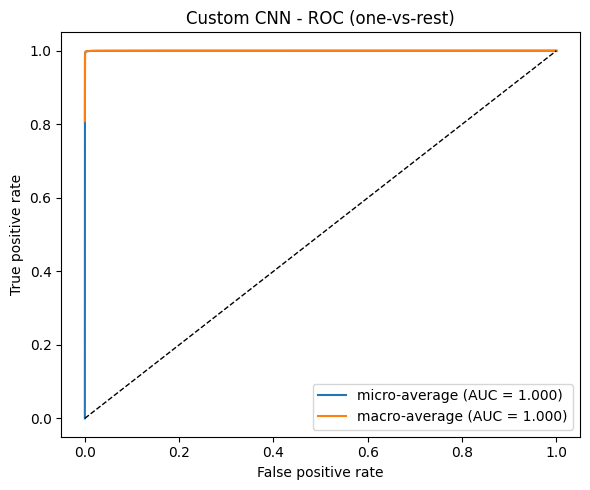

Mean per-class AUC: 0.9999


In [64]:
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

# micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), cnn_prob.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

# macro-average
fprs, tprs, aucs = [], [], []
for i in range(NUM_CLASSES):
    f, t, _ = roc_curve(y_test_bin[:, i], cnn_prob[:, i])
    fprs.append(f); tprs.append(t); aucs.append(auc(f, t))
all_fpr = np.unique(np.concatenate(fprs))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fprs[i], tprs[i])
mean_tpr /= NUM_CLASSES
auc_macro = auc(all_fpr, mean_tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_micro, tpr_micro, label="micro-average (AUC = %.3f)" % auc_micro)
plt.plot(all_fpr, mean_tpr, label="macro-average (AUC = %.3f)" % auc_macro)
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title("Custom CNN - ROC (one-vs-rest)")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_roc_curves.pdf"), dpi=150)
plt.show()
pd.DataFrame({"letter": LETTERS, "auc": aucs}).to_csv(
    os.path.join(TABLE_DIR, "per_class_auc.csv"), index=False)
print("Mean per-class AUC: %.4f" % np.mean(aucs))

                 Model  Accuracy  Macro F1  Weighted F1
            Custom CNN    0.9907    0.9875       0.9908
MobileNetV2 (transfer)    0.1963    0.1114       0.2287


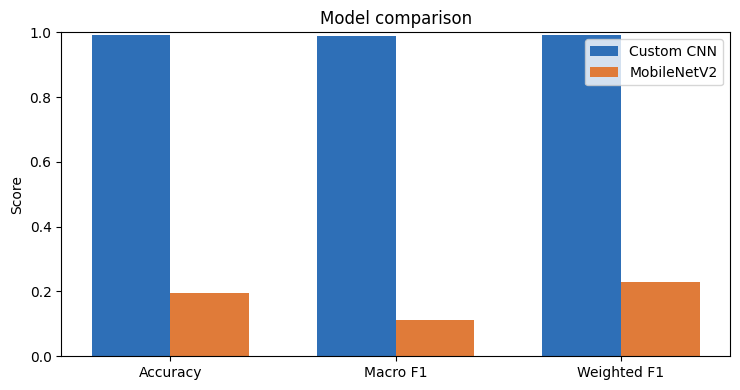

In [65]:
## 15. Model comparison (custom CNN vs MobileNetV2, RQ4)
def f1_scores(y_true, y_pred):
    r = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return r["accuracy"], r["macro avg"]["f1-score"], r["weighted avg"]["f1-score"]

cnn_acc, cnn_mf1, cnn_wf1   = f1_scores(y_test, cnn_pred)
mnet_acc, mnet_mf1, mnet_wf1 = f1_scores(y_test, mnet_pred)

comparison = pd.DataFrame({
    "Model":        ["Custom CNN", "MobileNetV2 (transfer)"],
    "Accuracy":     [cnn_acc,  mnet_acc],
    "Macro F1":     [cnn_mf1,  mnet_mf1],
    "Weighted F1":  [cnn_wf1,  mnet_wf1],
}).round(4)
comparison.to_csv(os.path.join(TABLE_DIR, "model_comparison.csv"), index=False)
print(comparison.to_string(index=False))

# grouped bar chart
metrics = ["Accuracy", "Macro F1", "Weighted F1"]
x = np.arange(len(metrics)); w = 0.35
plt.figure(figsize=(7.5, 4))
plt.bar(x - w/2, comparison.iloc[0, 1:].values, w, label="Custom CNN", color="#2E6FB7")
plt.bar(x + w/2, comparison.iloc[1, 1:].values, w, label="MobileNetV2", color="#E07B39")
plt.xticks(x, metrics); plt.ylim(0, 1.0); plt.ylabel("Score"); plt.legend()
plt.title("Model comparison")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_model_comparison.pdf"), dpi=150)
plt.show()

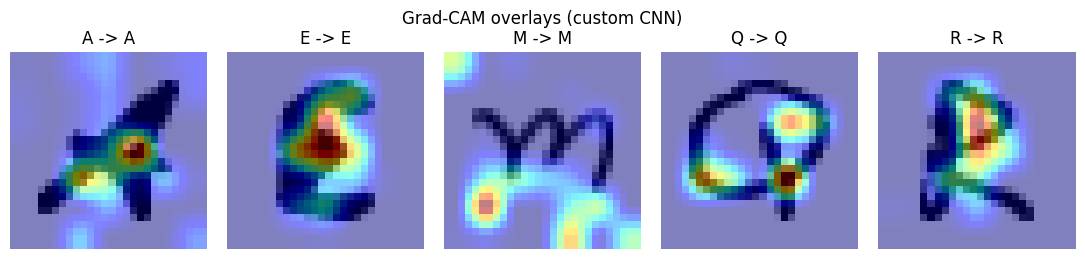

In [66]:
## 16. Grad-CAM (what the model looks at, RQ5)

def build_grad_model(model, last_conv_layer_name="conv3"):
    inp = tf.keras.Input(shape=(28, 28, 1))
    x = inp
    conv_output = None
    for layer in model.layers:           # Rescaling -> augmentation -> conv/pool -> ... -> softmax
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x              # capture the last conv feature maps
    return tf.keras.models.Model(inp, [conv_output, x])

grad_model = build_grad_model(cnn, "conv3")

def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = tf.squeeze(conv_out @ pooled[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# pick a few examples to display
show_idx = [np.where(y_test == c)[0][0] for c in [0, 4, 12, 16, 17]]   # A, E, M, Q, R
plt.figure(figsize=(11, 2.6))
for k, idx in enumerate(show_idx):
    img = X_test[idx:idx+1].astype("float32")          # raw 0-255; model rescales internally
    heat = make_gradcam_heatmap(img, grad_model)
    heat = tf.image.resize(heat[..., None], [28, 28]).numpy().squeeze()
    plt.subplot(1, len(show_idx), k + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray_r")
    plt.imshow(heat, cmap="jet", alpha=0.5)
    plt.title("%s -> %s" % (LETTERS[y_test[idx]], LETTERS[cnn_pred[idx]]))
    plt.axis("off")
plt.suptitle("Grad-CAM overlays (custom CNN)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_gradcam.pdf"), dpi=150, bbox_inches="tight")
plt.show()

Total misclassified: 518 / 55868 (0.93%)


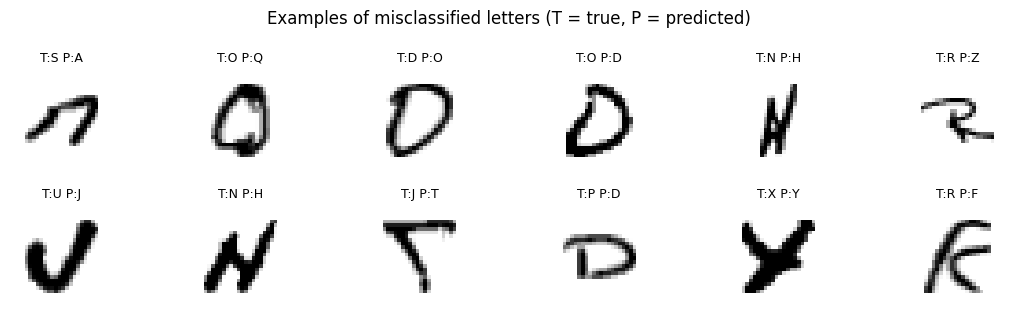

In [67]:
wrong = np.where(cnn_pred != y_test)[0]
print("Total misclassified: %d / %d (%.2f%%)" % (len(wrong), len(y_test), 100*len(wrong)/len(y_test)))

sel = wrong[:12]
plt.figure(figsize=(11, 3.2))
for k, idx in enumerate(sel):
    plt.subplot(2, 6, k + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray_r")
    plt.title("T:%s P:%s" % (LETTERS[y_test[idx]], LETTERS[cnn_pred[idx]]), fontsize=9)
    plt.axis("off")
plt.suptitle("Examples of misclassified letters (T = true, P = predicted)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_error_analysis.pdf"), dpi=150, bbox_inches="tight")
plt.show()

In [68]:
import subprocess
subprocess.run(["pip", "install", "shap", "--quiet"], check=True)
 
import shap
print("SHAP version:", shap.__version__)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
 
 
# ---- select background images: 2 random images per class ----
np.random.seed(42)
bg_idx = []
for c in range(NUM_CLASSES):
    class_idx = np.where(y_train == c)[0]
    chosen = np.random.choice(class_idx, size=min(2, len(class_idx)), replace=False)
    bg_idx.extend(chosen.tolist())
 
# normalise to float [0,1] — same as what the model's Rescaling layer does
bg_images = X_train[bg_idx].astype("float32") / 255.0   # shape (52, 28, 28, 1)
 
# ---- select test images: one correctly classified image per class
#      (classes A=0, E=4, M=12, Q=16, R=17 — same as Grad-CAM) ----
explain_classes = [0, 4, 12, 16, 17]   # A, E, M, Q, R
explain_idx = []
for c in explain_classes:
    # find first test image of class c that was predicted correctly
    candidates = np.where((y_test == c) & (cnn_pred == c))[0]
    explain_idx.append(candidates[0])
 
explain_images = X_test[explain_idx].astype("float32") / 255.0   # shape (5, 28, 28, 1)
explain_labels = [LETTERS[y_test[i]] for i in explain_idx]
 
print("Background images shape:", bg_images.shape)
print("Explain images shape   :", explain_images.shape)
print("Explain labels         :", explain_labels)

SHAP version: 0.51.0
Background images shape: (52, 28, 28, 1)
Explain images shape   : (5, 28, 28, 1)
Explain labels         : ['A', 'E', 'M', 'Q', 'R']


In [69]:
explainer = shap.DeepExplainer(cnn, bg_images)
 
# Compute SHAP values for the 5 explain images
# shap_values is a list of 26 arrays (one per class), each (5, 28, 28, 1)
print("Computing SHAP values — this may take a few minutes...")
shap_values = explainer.shap_values(explain_images)
print("Done. shap_values list length:", len(shap_values),
      " | each array shape:", shap_values[0].shape)

Computing SHAP values — this may take a few minutes...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_377
Received: inputs=['Tensor(shape=(52, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_377
Received: inputs=['Tensor(shape=(104, 28, 28, 1))']
  warnings.warn(msg)


Done. shap_values list length: 5  | each array shape: (28, 28, 1, 26)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_377
Received: inputs=['Tensor(shape=(5, 28, 28, 1))']
  warnings.warn(msg)


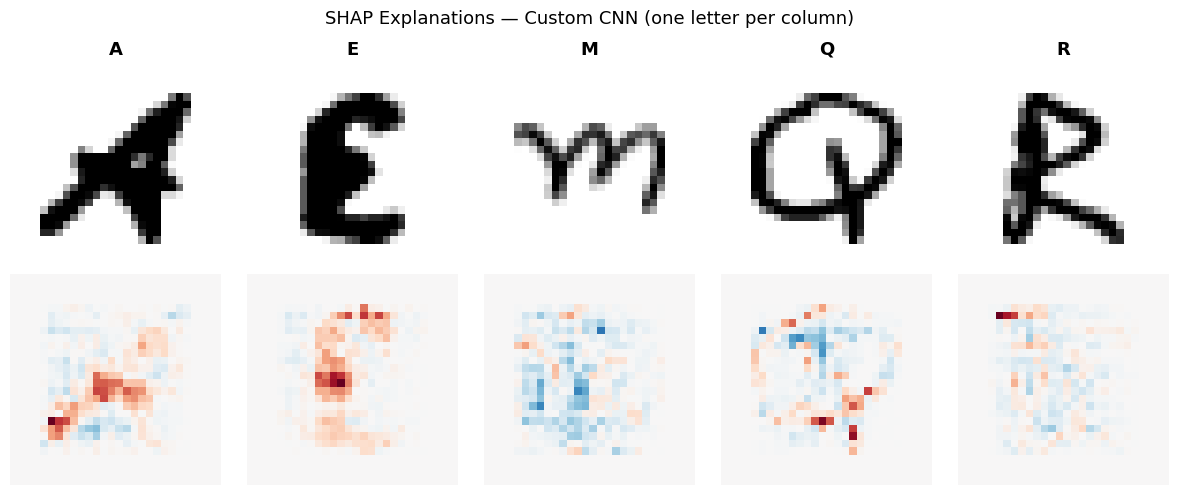

Saved 11_shap_summary.pdf


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_377
Received: inputs=['Tensor(shape=(2, 28, 28, 1))']
  warnings.warn(msg)


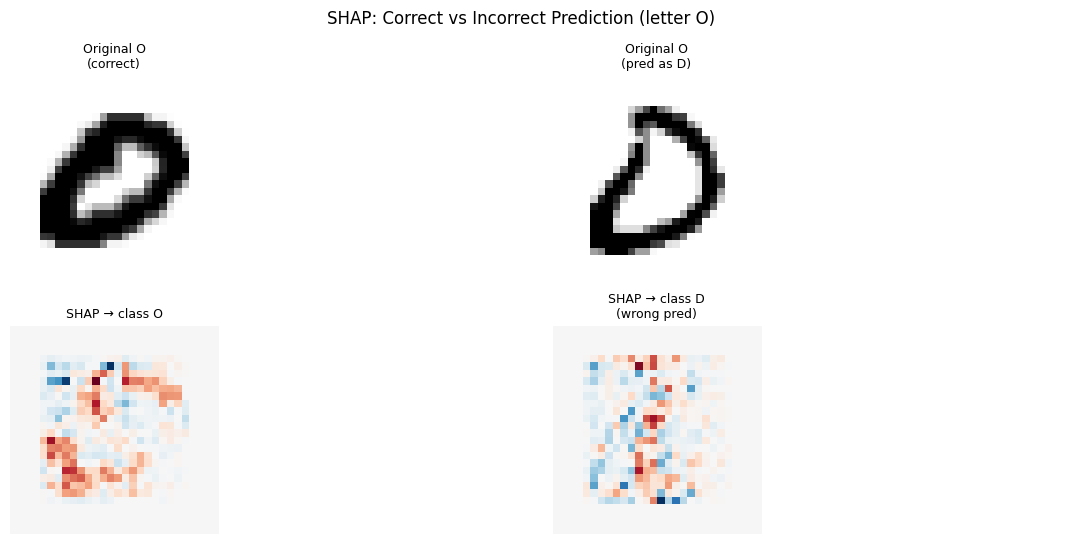

Saved 12_shap_correct_vs_wrong.pdf


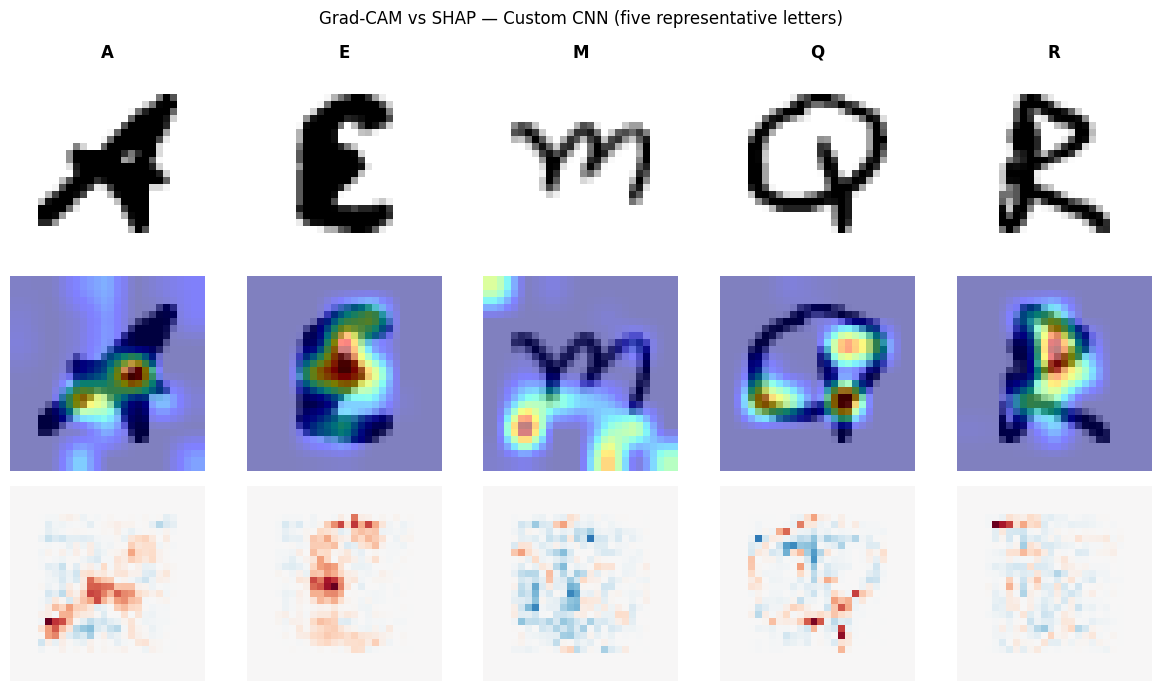

Saved 13_shap_gradcam_comparison.pdf
  11_shap_summary.pdf — exists: True
  12_shap_correct_vs_wrong.pdf — exists: True
  13_shap_gradcam_comparison.pdf — exists: True


In [70]:
def get_shap_map(shap_values, img_idx, class_idx):
    """
    Return the (28,28) SHAP map for explain image img_idx and class class_idx.
    Handles Keras 3 output shape: list of (28, 28, 1, 26) per image.
    """
    return shap_values[img_idx][:, :, 0, class_idx]   # -> (28, 28)
 
 
def symm_vmax(arr):
    """Symmetric colour scale so zero maps to white."""
    return max(abs(arr.min()), abs(arr.max())) + 1e-8
 
 
# ----------------------------------------------------------------
# Figure 11 — SHAP summary grid
# 2 rows x 5 cols: original letter on top, SHAP map on bottom
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, len(explain_classes), figsize=(12, 5))
 
for col, (img_idx, cls_letter) in enumerate(zip(range(len(explain_classes)), explain_labels)):
    true_class = explain_classes[col]
    shap_map   = get_shap_map(shap_values, img_idx, true_class)
    orig_img   = explain_images[img_idx, :, :, 0]
    vm = symm_vmax(shap_map)
 
    # row 0 — original image
    axes[0, col].imshow(orig_img, cmap="gray_r")
    axes[0, col].set_title(cls_letter, fontsize=13, fontweight="bold")
    axes[0, col].axis("off")
 
    # row 1 — SHAP heatmap (red = positive evidence, blue = negative)
    axes[1, col].imshow(shap_map, cmap="RdBu_r", vmin=-vm, vmax=vm)
    axes[1, col].axis("off")
 
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("SHAP\n(red=+, blue=−)", fontsize=10)
fig.suptitle("SHAP Explanations — Custom CNN (one letter per column)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "11_shap_summary.pdf"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved 11_shap_summary.pdf")
 
 
# ----------------------------------------------------------------
# Figure 12 — Correct vs wrong prediction SHAP comparison
# Best confused pair from results: O (class 14) misread as D (class 3)
# ----------------------------------------------------------------
 
correct_O_idx = np.where((y_test == 14) & (cnn_pred == 14))[0][0]
wrong_O_candidates = np.where((y_test == 14) & (cnn_pred == 3))[0]
 
if len(wrong_O_candidates) > 0:
    wrong_O_idx = wrong_O_candidates[0]
 
    # build a small 2-image batch to explain
    two_images = np.array([
        X_test[correct_O_idx].astype("float32") / 255.0,
        X_test[wrong_O_idx].astype("float32")   / 255.0,
    ])
 
    shap_two = explainer.shap_values(two_images)
 
    fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
 
    # col 0: correct O original
    axes[0, 0].imshow(two_images[0, :, :, 0], cmap="gray_r")
    axes[0, 0].set_title("Original O\n(correct)", fontsize=9)
    axes[0, 0].axis("off")
 
    # col 1: SHAP for correct O
    sm = shap_two[0][:, :, 0, 14]
    vm = symm_vmax(sm)
    axes[1, 0].imshow(sm, cmap="RdBu_r", vmin=-vm, vmax=vm)
    axes[1, 0].set_title("SHAP → class O", fontsize=9)
    axes[1, 0].axis("off")
 
    # col 1 top: blank separator
    axes[0, 1].axis("off")
    axes[1, 1].axis("off")
 
    # col 2: wrong O original
    axes[0, 2].imshow(two_images[1, :, :, 0], cmap="gray_r")
    axes[0, 2].set_title("Original O\n(pred as D)", fontsize=9)
    axes[0, 2].axis("off")
 
    # col 3: SHAP for wrong O — looking at class D
    sm2 = shap_two[1][:, :, 0, 3]
    vm2 = symm_vmax(sm2)
    axes[1, 2].imshow(sm2, cmap="RdBu_r", vmin=-vm2, vmax=vm2)
    axes[1, 2].set_title("SHAP → class D\n(wrong pred)", fontsize=9)
    axes[1, 2].axis("off")
 
    # col 3 top: blank
    axes[0, 3].axis("off")
    axes[1, 3].axis("off")
 
    fig.suptitle("SHAP: Correct vs Incorrect Prediction (letter O)", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "12_shap_correct_vs_wrong.pdf"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved 12_shap_correct_vs_wrong.pdf")
else:
    print("No O→D misclassification found — skipping Figure 12.")
 
 
# ----------------------------------------------------------------
# Figure 13 — Side-by-side: original | Grad-CAM | SHAP
# 3 rows x 5 cols for the same 5 letters used in Grad-CAM earlier
# ----------------------------------------------------------------
 
fig, axes = plt.subplots(3, len(explain_classes), figsize=(12, 7))
 
for col, (img_idx, cls_letter) in enumerate(zip(range(len(explain_classes)), explain_labels)):
    true_class = explain_classes[col]
    orig_img   = explain_images[img_idx, :, :, 0]          # float [0,1]
    raw_img    = X_test[explain_idx[img_idx]:explain_idx[img_idx]+1].astype("float32")
 
    # -- Grad-CAM (reuse function already defined earlier) --
    heat     = make_gradcam_heatmap(raw_img, grad_model, pred_index=true_class)
    heat_up  = tf.image.resize(heat[..., None], [28, 28]).numpy().squeeze()
 
    # -- SHAP (use already-computed shap_values) --
    shap_map = get_shap_map(shap_values, img_idx, true_class)
    vm       = symm_vmax(shap_map)
 
    # row 0 — original
    axes[0, col].imshow(orig_img, cmap="gray_r")
    axes[0, col].set_title(cls_letter, fontsize=12, fontweight="bold")
    axes[0, col].axis("off")
 
    # row 1 — Grad-CAM overlay
    axes[1, col].imshow(orig_img, cmap="gray_r")
    axes[1, col].imshow(heat_up, cmap="jet", alpha=0.5)
    axes[1, col].axis("off")
 
    # row 2 — SHAP
    axes[2, col].imshow(shap_map, cmap="RdBu_r", vmin=-vm, vmax=vm)
    axes[2, col].axis("off")
 
axes[0, 0].set_ylabel("Original",  fontsize=9)
axes[1, 0].set_ylabel("Grad-CAM",  fontsize=9)
axes[2, 0].set_ylabel("SHAP",      fontsize=9)
fig.suptitle("Grad-CAM vs SHAP — Custom CNN (five representative letters)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13_shap_gradcam_comparison.pdf"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved 13_shap_gradcam_comparison.pdf")
 
for f in ["11_shap_summary.pdf", "12_shap_correct_vs_wrong.pdf",
          "13_shap_gradcam_comparison.pdf"]:
    path = os.path.join(FIG_DIR, f)
    print(" ", f, "— exists:", os.path.isfile(path))

In [71]:
# Save the final models
cnn.save(os.path.join(MODEL_DIR, "cnn_model.keras"))
mnet.save(os.path.join(MODEL_DIR, "mobilenetv2_model.keras"))

# Save a compact metrics summary
metrics_summary = {
    "custom_cnn":  {"test_accuracy": float(cnn_acc),  "macro_f1": float(cnn_mf1),  "weighted_f1": float(cnn_wf1),  "auc_macro": float(auc_macro)},
    "mobilenetv2": {"test_accuracy": float(mnet_acc), "macro_f1": float(mnet_mf1), "weighted_f1": float(mnet_wf1)},
    "config": {"seed": SEED, "batch": BATCH, "epochs": EPOCHS,
               "img_tl": IMG_TL, "class_weights": USE_CLASS_WEIGHTS, "sample_fraction": SAMPLE_FRACTION},
}
with open(os.path.join(WORK, "metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=2)
print(json.dumps(metrics_summary, indent=2))

print("\nSaved files in", WORK, ":")
for p in sorted(glob.glob(os.path.join(WORK, "**", "*"), recursive=True)):
    if os.path.isfile(p):
        print(" ", p)

{
  "custom_cnn": {
    "test_accuracy": 0.9907281449130092,
    "macro_f1": 0.9875455333119258,
    "weighted_f1": 0.9907500035388952,
    "auc_macro": 0.9999439401407371
  },
  "mobilenetv2": {
    "test_accuracy": 0.19630199756569056,
    "macro_f1": 0.11140029038229467,
    "weighted_f1": 0.22866666411952014
  },
  "config": {
    "seed": 42,
    "batch": 128,
    "epochs": 20,
    "img_tl": 32,
    "class_weights": true,
    "sample_fraction": 1.0
  }
}

Saved files in /kaggle/working :
  /kaggle/working/figures/01_class_distribution.pdf
  /kaggle/working/figures/02_sample_letters.pdf
  /kaggle/working/figures/03_augmentation_examples.pdf
  /kaggle/working/figures/04_cnn_curves.pdf
  /kaggle/working/figures/04b_mobilenetv2_curves.pdf
  /kaggle/working/figures/05_confusion_matrix.pdf
  /kaggle/working/figures/05b_mnet_confusion_matrix.pdf
  /kaggle/working/figures/06_per_class_recall.pdf
  /kaggle/working/figures/06b_mnet_per_class_recall.pdf
  /kaggle/working/figures/07_roc_curves